# Factory Scenario Generator
The following jupyter notebook generates factory sequences with the following manufacturing cells:
- Assembly: Manufacturing of assemblies or sub-assemblies
- Electronics assembly: PCB fabrication, soldering etc.
- Material Process: Heat treatment, painting, surface treatments etc.
- Material Join: Welding, fastening, riviting etc.

Each of these processes may take the following inventory items:
- raw_material
- electronic component
- fastener
- misc_component

Here is an example of a generated scenario: <br>
<img src = "scenario_n.png" width = "40%">

## 1. Importing Packages

In [13]:
import json
import random
import os
from typing import Dict, List, Tuple, Set
from tqdm.notebook import trange, tqdm
from copy import deepcopy
import math
import graphviz
from IPython.display import display, SVG
import networkx as nx
import matplotlib.pyplot as plt

## 2. Process Definition
This cell defines the structure and functions for generating and updating manufacturing processes:

1. **Process List**:
    ```python
    process_list = ['assembly', 'electronics', 'material-process', 'material-join']
    ```
    - A list of different types of manufacturing processes.

2. **Base Process Template**:
    ```python
    base_process = {
        'name': None,
        'process_id': None,
        'wip_output_to': None,
        'inventory_input_items': {
            'raw_material': 0,
            'electronic_component': 0,
            'misc_component': 0,
            'fastener': 0
        },
        'WIP_input_items': {
            'material-process_part': 0,
            'material-join_part': 0,
            'electronics_part': 0,
            'assembly_part': 0
        },
        'output_item': None,
        'base_processing_time': 0,
        'complexity': 0,
        'processing_capacity': 1
    }
    ```
    - A template for creating new processes with default values.

3. **Functions**:
    - `processing_time_update(data)`: Updates the processing time based on input items.
    - `complexity_update(data)`: Updates the complexity based on input items.
    - `process_gen(process_name, process_count)`: Generates a new process based on the given name and count.
    - `biased_randint(process_count)`: Generates a biased random integer, favoring 1 over 0 when the process count is less than 4.


In [14]:
process_list = ['assembly', 'electronics', 'material-process', 'material-join']

base_process = {
                'name': None,
                'process_id': None,
                'wip_output_to': None,
                'inventory_input_items': {
                    'raw_material': 0,
                    'electronic_component': 0,
                    'misc_component': 0,
                    'fastener': 0
                },
                'WIP_input_items': {
                    'material-process_part': 0,
                    'material-join_part': 0,
                    'electronics_part': 0,
                    'assembly_part': 0
                },
                'output_item': None,
                'base_processing_time': 0,
                'complexity': 0,
                'processing_capacity': 1
            }

def processing_time_update (data):
    count = 0
    processing_time = data['base_processing_time']
    for key in data['WIP_input_items']:
        if data['WIP_input_items'][key] > 0:
            count += 1 

    for key in data['inventory_input_items']:
        if data['inventory_input_items'][key] > 1:
             count += 1 if key == 'electronic_component' else 0.5

    if count < 2:
        # print(processing_time)
        return processing_time
    
    else:
        processing_time += (10*processing_time/100)*count
        # print(processing_time)
        return processing_time
    
def complexity_update (data):
    count = 0
    complexity = data['complexity']
    for key in data['WIP_input_items']:
        count += data['WIP_input_items'][key]*0.015

    for key in data['inventory_input_items']:
        if key == 'fastener':
            factor = 0.005
        elif key == 'electronic_component':
            factor = 0.02
        else:
            factor = 0.01
        count += data['inventory_input_items'][key]*factor

    complexity += count
    # print(complexity)
    return complexity

def process_gen(process_name, process_count):
    unresolvedLinks = []
    process = deepcopy(base_process)
    process_count +=1
    process['name'] = process_name
    process['process_id'] = f'{process_name}_{process_count}'
    process['output_item'] = f'{process_name}_part'

    if process_name == 'assembly':
        process['base_processing_time'] = 1
        process['complexity'] = 0.1
        process['WIP_input_items']['material-process_part'] = biased_randint(process_count)
        if process['WIP_input_items']['material-process_part'] !=0: unresolvedLinks.append([process['process_id'],'material-process'])
        process['WIP_input_items']['material-join_part'] = biased_randint(process_count)
        if process['WIP_input_items']['material-join_part'] !=0: unresolvedLinks.append([process['process_id'],'material-join'])
        process['WIP_input_items']['electronics_part'] = biased_randint(process_count)
        if process['WIP_input_items']['electronics_part'] !=0: unresolvedLinks.append([process['process_id'],'electronics'])
        process['WIP_input_items']['assembly_part'] = biased_randint(process_count)
        if process['WIP_input_items']['assembly_part'] !=0: unresolvedLinks.append([process['process_id'],'assembly'])
        process['inventory_input_items']['misc_component'] = random.randint(2,3)
        process['inventory_input_items']['fastener'] = random.randint(4,6)
        process['processing_capacity'] = 2
    
    if process_name == 'electronics':
        process['base_processing_time'] = .75
        process['processing_capacity'] = 5
        process['complexity'] = 0.4
        process['WIP_input_items']['electronics_part'] = biased_randint(process_count)
        if process['WIP_input_items']['electronics_part'] !=0: unresolvedLinks.append([process['process_id'],'electronics'])
        process['inventory_input_items']['misc_component'] = random.randint(1,2)
        process['inventory_input_items']['fastener'] = random.randint(1,2)
        process['inventory_input_items']['electronic_component'] = random.randint(1,2)

    if process_name == 'material-process':
        process['base_processing_time'] = .5
        process['complexity'] = 0.2
        process['WIP_input_items']['material-join_part'] = biased_randint(process_count)
        process['inventory_input_items']['raw_material'] = 1 if process['WIP_input_items']['material-join_part']== 0 else 0
        if process['WIP_input_items']['material-join_part'] !=0: unresolvedLinks.append([process['process_id'],'material-join'])

    if process_name == 'material-join':
        process['base_processing_time'] = .25
        process['complexity'] = 0.1
        process['inventory_input_items']['fastener'] = random.randint(2,3)
        process['WIP_input_items']['material-join_part'] = biased_randint(process_count)
        process['inventory_input_items']['raw_material'] = 1 if process['WIP_input_items']['material-join_part']== 1 else 2
        if process['WIP_input_items']['material-join_part'] !=0: unresolvedLinks.append([process['process_id'],'material-join'])

    process['base_processing_time'] = processing_time_update(process)
    process['complexity'] = complexity_update(process)

    return process, process_count, unresolvedLinks 

def biased_randint(process_count):
    if process_count < 4:
        return random.choices([0, 1], weights=[1, 4])[0]  # 80% chance of 1
    else:
        return random.randint(0, 1)


## 3. Factory Generation
This cell defines a function `generate_factory` that creates a factory scenario with a specified depth and scenario number. Here's a brief description:

- **Initialization**:
  - Initializes empty lists for layers and links.
  - Creates a factory dictionary with a scenario ID and assembly sequence.
  - Initializes process counts for different process types.

- **Process Generation**:
  - Iterates through the specified depth to generate processes.
  - For each depth:
    - If it's the first layer, generates an 'assembly' process.
    - For intermediate layers, generates processes based on existing links.
    - For the last layer, finalizes the processes and resolves links.

- **Output**:
  - Reverses the layers and assigns them to the factory's assembly sequence.
  - Returns the generated factory scenario.

In [15]:
def generate_factory (depth_max, scenario_num):
    layers = []
    links = []
    factory ={
        'scenario_id': f'scenario_{scenario_num}',
        'assembly_sequence': 0
    }
    process_counts = {
        'assembly': 0, 
        'electronics': 0, 
        'material-process': 0, 
        'material-join': 0
    }
    for depth in range(depth_max):
        inlayerProcess = []
        # print(depth)
        if depth == 0:
            process_name = 'assembly'
            process, c, link = process_gen(process_name, 0)
            links.extend(link)
            process_counts[process_name] = c
            inlayerProcess.append(process)
    
            # print(links)
        elif depth < depth_max-1:
            layer_size = len(links) if len(links) <2 else random.randint(1, len(links))
            # print(layer_size)
            linksInLayer = []
            for i in range(layer_size):
                process_link = random.choice(links)
                process_name = process_link[1]
                process, c, link = process_gen(process_name, process_counts[process_name])
                process['wip_output_to'] = process_link[0]
                links.remove(process_link)
                linksInLayer.extend(link)
                process_counts[process_name] =c
                inlayerProcess.append(process)
            links.extend(linksInLayer)
        elif depth == depth_max-1:
            layer_size = len(links)
            for i in range(layer_size):
                for l in links:
                    if 'assembly' in l[1]:
                        process_name = l[1]
                        process, c, link = process_gen(process_name, process_counts[process_name])
                        process['wip_output_to'] = l[0]
                        process['WIP_input_items']['material-process_part'] = 0
                        process['WIP_input_items']['material-join_part'] = 0
                        process['WIP_input_items']['electronics_part'] = 0
                        process['WIP_input_items']['assembly_part'] = 0
                        process['inventory_input_items']['misc_component'] = random.randint(2,3)
                        process['inventory_input_items']['fastener'] = random.randint(4,6)
                        process_counts[process_name] =c
                    elif 'electronics' in l[1]:
                        process_name = l[1]
                        process, c, link = process_gen(process_name, process_counts[process_name])
                        process['wip_output_to'] = l[0]
                        process['WIP_input_items']['electronics_part'] = 0
                        process['inventory_input_items']['misc_component'] = random.randint(1,2)
                        process['inventory_input_items']['fastener'] = random.randint(1,2)
                        process['inventory_input_items']['electronic_component'] = random.randint(1,2)
                        process_counts[process_name] =c
                    elif 'material-process' in l[1]:
                        process_name = l[1]
                        process, c, link = process_gen(process_name, process_counts[process_name])
                        process['wip_output_to'] = l[0]
                        process['inventory_input_items']['raw_material'] = 1
                        process['WIP_input_items']['material-join_part'] = 0
                        process_counts[process_name] =c
                    elif 'material-join' in l[1]:
                        process_name = l[1]
                        process, c, link = process_gen(process_name, process_counts[process_name])
                        process['wip_output_to'] = l[0]
                        process['inventory_input_items']['raw_material'] = 2
                        process['WIP_input_items']['material-join_part'] = 0
                        process_counts[process_name] =c
                    inlayerProcess.append(process)
                    links.remove(l)
        layers.append(inlayerProcess)
        if depth > 0 and len(links) == 0:
            break
    
    factory['assembly_sequence'] = list(reversed(layers))
    return factory

## 4. Function to vizualize the factory

In [16]:
def create_assembly_graph(data):
    dot = graphviz.Digraph(comment=f"Assembly Graph - {data['scenario_id']}")
    
    # Create inventory nodes
    inventory_types = ['raw_material', 'electronic_component', 'misc_component', 'fastener']
    for inv_type in inventory_types:
        dot.node(inv_type, inv_type, shape='box', style='filled', color='lightblue', width='1.5', height='0.5')
    
    # Create process nodes and edges
    for step, processes in enumerate(data['assembly_sequence'], 1):
        if not isinstance(processes, list):
            processes = [processes]
            
        for process in processes:
            node_id = f"{process['name']}_{process['process_id']}"
            dot.node(node_id, node_id.replace('_', '\n'), shape='ellipse', style='filled', color='lightgrey', width='1.5', height='0.5')
            
            # Add inventory edges
            for inv_type, qty in process['inventory_input_items'].items():
                if qty > 0:
                    dot.edge(inv_type, node_id, label=str(qty), color='blue', style='dashed')
            
            # Add process edges
            if process['wip_output_to']:
                for other_processes in data['assembly_sequence']:
                    if not isinstance(other_processes, list):
                        other_processes = [other_processes]
                    for other_process in other_processes:
                        if other_process['process_id'] == process['wip_output_to']:
                            other_id = f"{other_process['name']}_{other_process['process_id']}"
                            dot.edge(node_id, other_id, color='black')
    
    return dot

## 5. Functions to generate factory scenarios and save them
The following functions are used to generate factory scenarios with different part demands and ten save them

In [17]:
def save_scenario (scenario):
    location = 'factory_scenario'
    os.makedirs(location, exist_ok=True)

    fileName = "{}/{}.json".format(location, scenario['scenario_id'])

    with open(fileName,'w') as f:
        json.dump(scenario, f, indent=2)

def initial_conditions(scenario, demand):
    location = 'initial_conditions'
    os.makedirs(location, exist_ok=True)
    sub_location = f'{location}/{scenario["scenario_id"]}'
    os.makedirs(sub_location, exist_ok=True)
    fileName = f'{sub_location}/{scenario["scenario_id"]}_demand_{demand}.json'

    for layer in scenario['assembly_sequence']:
        for process in layer:
            process.pop('processing_capacity', None)
            process.pop('base_processing_time', None)
            process.pop('complexity', None)
            for key in process['inventory_input_items']:
                process['inventory_input_items'][key] *= demand
            for key in process['WIP_input_items']:
                process['WIP_input_items'][key] = 0

    with open(fileName, 'w') as f:
        json.dump(scenario, f, indent=2)

## 6. Factory Generation
The next block generates factories with different demands and tree depths to increase or reduce complexity

In [18]:
demands = list(range(5,1005,5))
scenarios = list(range(1,51,1))
min_depth = 3
max_depth = 8

for scenario_num in tqdm(scenarios):
    scenario = generate_factory(random.randint(min_depth, max_depth), scenario_num)
    save_scenario(scenario)
    for demand in demands:
        scenario_1 = deepcopy(scenario)
        initial_conditions(scenario_1, demand)

  0%|          | 0/50 [00:00<?, ?it/s]

## 7. Visualize a given factory
To change the factory scenario being vizualized, just change [facScen]

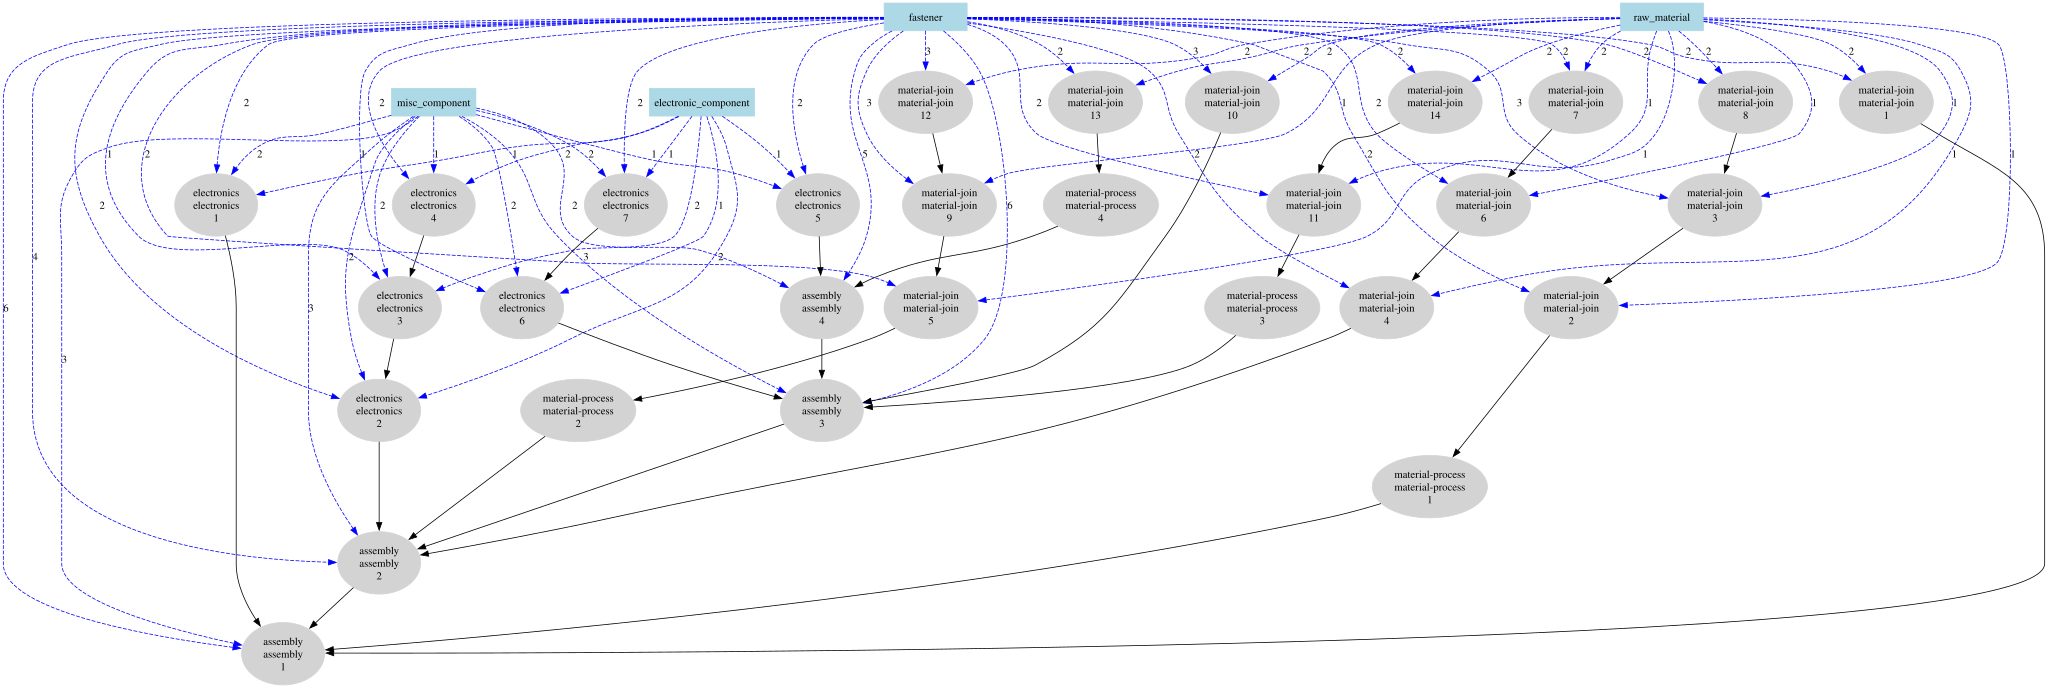

In [19]:
facScen = '32'

with open(f'factory_scenario/scenario_{facScen}.json', 'r') as f:
    data = json.load(f)

graph = create_assembly_graph(data)

# Render the graph
svg = graph.pipe(format='svg')
display(SVG(svg))